# Classificação de sinais de radares

Para essa atividade de classificação, foi escolhido o problema de classificação de sinais de radares, com o dataset `ionosphere.csv`. Esse dataset contém dados coletados por um sistema de radar em Goose Bay, Labrador, com o objetivo principal distinguir entre sinais de radar que mostram evidências de algum tipo de estrutura na ionosfera (camada da atmosfera repleta de partículas carregadas) e sinais que não mostram. Esse problema possui os atributos `a01` a `a34`, que representam leituras de radar, e a variável-alvo: `classe`, que classifica se o sinal é **bom** ou **ruim**, para o treinamento de um modelo de aprendizado de máquina.

## Carregamento do Dataset
----

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("ionosphere.csv")
colunas = df.columns
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 35 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   a01     351 non-null    float64
 1   a02     351 non-null    float64
 2   a03     351 non-null    float64
 3   a04     351 non-null    float64
 4   a05     351 non-null    float64
 5   a06     351 non-null    float64
 6   a07     351 non-null    float64
 7   a08     351 non-null    float64
 8   a09     351 non-null    float64
 9   a10     351 non-null    float64
 10  a11     351 non-null    float64
 11  a12     351 non-null    float64
 12  a13     351 non-null    float64
 13  a14     351 non-null    float64
 14  a15     351 non-null    float64
 15  a16     351 non-null    float64
 16  a17     351 non-null    float64
 17  a18     351 non-null    float64
 18  a19     351 non-null    float64
 19  a20     351 non-null    float64
 20  a21     351 non-null    float64
 21  a22     351 non-null    float64
 22  a23     351 n

Com o código acima, é possível perceber que a quantidade de linhas é de 351 entradas, e a de colunas é um total de 35 colunas. Todos os atributos de a01 a a34 são variáveis do típo `float`, com a variável `classe` sendo uma string. Como já dito antes, os atributos a01 a a34 são leituras de radares, enquanto a classe é a classificação da qualidade das leituras. Abaixo, segue as primeiras linhas do dataset.

In [3]:
df.head() # Primeiras linhas do dataset

,a01,a02,a03,a04,a05,a06,a07,a08,a09,a10,...,a26,a27,a28,a29,a30,a31,a32,a33,a34,class
0,1.0,0.0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,g
1,1.0,0.0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
2,1.0,0.0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
3,1.0,0.0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
4,1.0,0.0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g


## Análise exploratória de dados
---

In [4]:
df.describe()

,a01,a02,a03,a04,a05,a06,a07,a08,a09,a10,...,a25,a26,a27,a28,a29,a30,a31,a32,a33,a34
count,351.000000,351.0,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,...,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000
mean,0.891738,0.0,0.641342,0.044372,0.601068,0.115889,0.550095,0.119360,0.511848,0.181345,...,0.396135,-0.071187,0.541641,-0.069538,0.378445,-0.027907,0.352514,-0.003794,0.349364,0.014480
std,0.311155,0.0,0.497708,0.441435,0.519862,0.460810,0.492654,0.520750,0.507066,0.483851,...,0.578451,0.508495,0.516205,0.550025,0.575886,0.507974,0.571483,0.513574,0.522663,0.468337
min,0.000000,0.0,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,1.000000,0.0,0.472135,-0.064735,0.412660,-0.024795,0.211310,-0.054840,0.087110,-0.048075,...,0.000000,-0.332390,0.286435,-0.443165,0.000000,-0.236885,0.000000,-0.242595,0.000000,-0.165350
50%,1.000000,0.0,0.871110,0.016310,0.809200,0.022800,0.728730,0.014710,0.684210,0.018290,...,0.553890,-0.015050,0.708240,-0.017690,0.496640,0.000000,0.442770,0.000000,0.409560,0.000000
75%,1.000000,0.0,1.000000,0.194185,1.000000,0.334655,0.969240,0.445675,0.953240,0.534195,...,0.905240,0.156765,0.999945,0.153535,0.883465,0.154075,0.857620,0.200120,0.813765,0.171660
max,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Com o código acima, é possível analisar todas as estatísticas descritivas

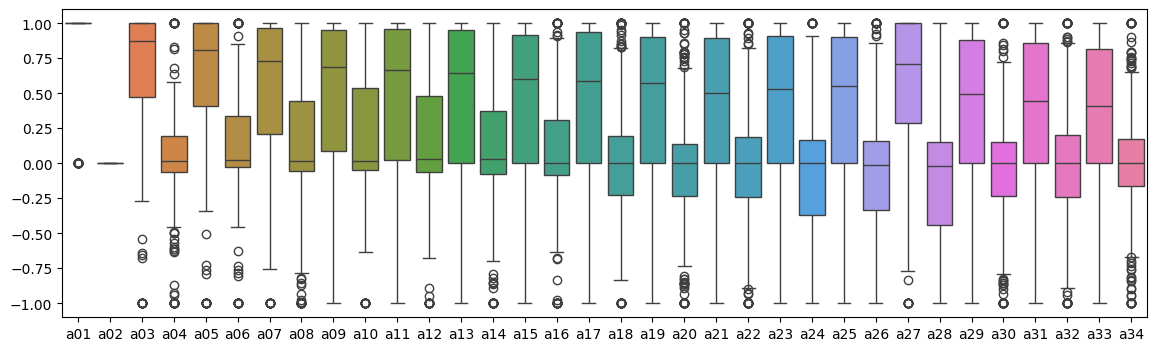

In [5]:
plt.figure(figsize=(14, 4))
sns.boxplot(data=df.drop(columns=['class'])) # Retirando coluna alvo por ser string
plt.show()

Com o código acima, é possível analisar a distribuição de todas as variáveis, excluindo a classificação, por ser uma string.  
  
Algo estranho está acontecendo com as colunas `a01` e `a02`, não são decimais contínuas que nem as outras. Analisando as estatísticas descritivas, é possível perceber que a coluna `a02` é composta somente por 0s. Isso irá introduzir ruído para o modelo e aumentar o custo computacional sem ganho na performance. Podêmos retirá-la sem problema.  
  
Já a `a01`, varia entre 0 ou 1. Isso porque ela indica se houve algum sinal inicial de pulso, indicando se o radar detectou algum sinal válido que tentou processar ou não. Então, apesar de ser uma variável binária simples, ela ainda é importante para a classificação do modelo de ML, servindo como um "atalho" para descartar ruído. Podemos deixá-la

Para analisar melhor a correlação entre as variáveis e o impacto na classificação, vamos trocar as strings da variável `classe` por 0s ou 1s.

In [6]:
# Substituindo as strings da variavel class por 0 e 1s
df["class"] = df["class"].replace('g', 1)
df["class"] = df["class"].replace('b', 0)

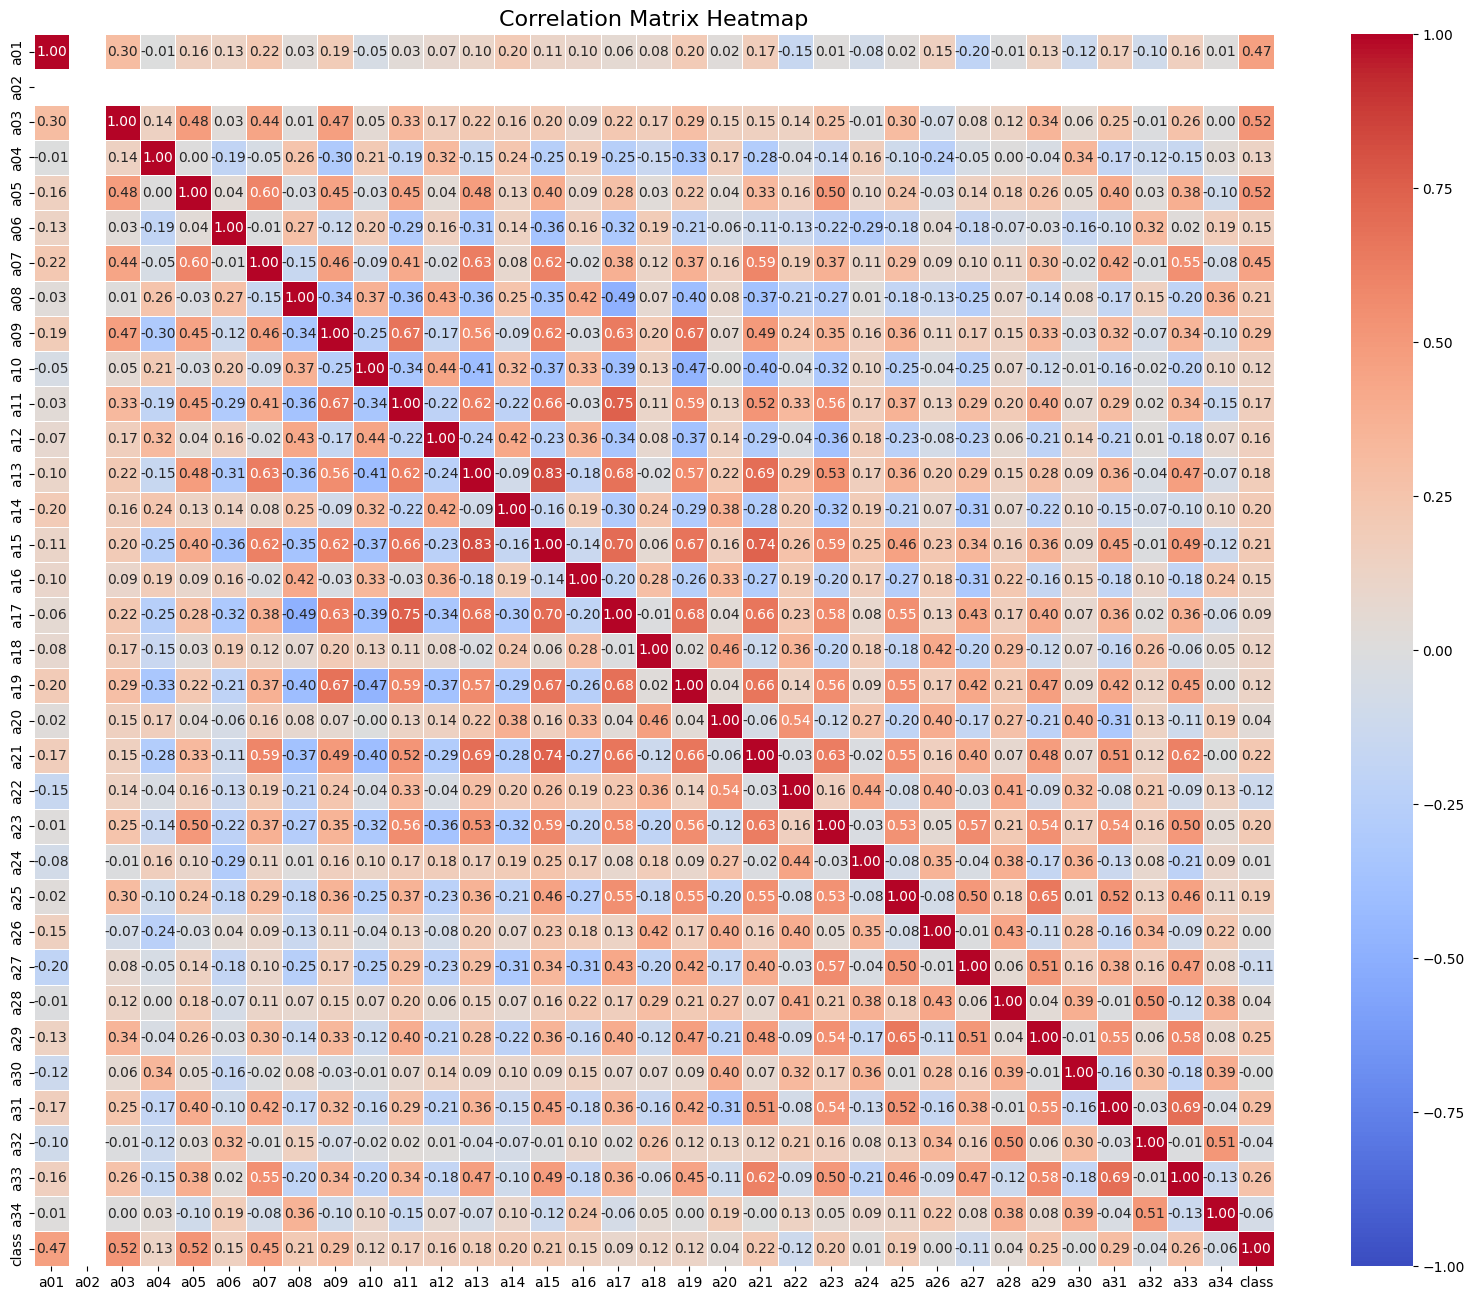

In [7]:

# As distribuições parecem melhores agora. Vamos exibir a nova matriz de correlação para análise.
def imprimeMatrizCorr():
    correlation_matrix = df.corr()
    plt.figure(figsize=(20, 16))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin = -1)
    plt.title('Correlation Matrix Heatmap', fontsize=16)
    plt.show()
    return
imprimeMatrizCorr()

Com esse gráfico, percebe-se que as variáveis ainda não possuem tanta correlação umas com as outras. Vamos tentar remover outliers para ver se altera a correlação.

## Pré-processamento
---

In [8]:
for coluna in colunas: # Esse conjunto de códigos normaliza os dados, transformando outliers em valores nulos, para depois serem removidos
    media_coluna = round(df[coluna].mean(), 1)
    std_coluna = df[coluna].std()
    dist_tolerancia = 1.5 * std_coluna
    upper_outliers = df[coluna][df[coluna] > media_coluna + dist_tolerancia]
    lower_outliers = df[coluna][df[coluna] < media_coluna - dist_tolerancia]
    outliers = pd.concat([upper_outliers, lower_outliers], ignore_index=True)

    df.loc[df[coluna].isin(outliers), coluna] = np.nan

O código acima identifica outliers e os remove, substituindo seus valores por valores nulos, que serão removidos no próximo código. Com a experiência com o meu último trabalho, aprendi que remover outliers é melhor do que substituí-los por valores artificiais, como a média.

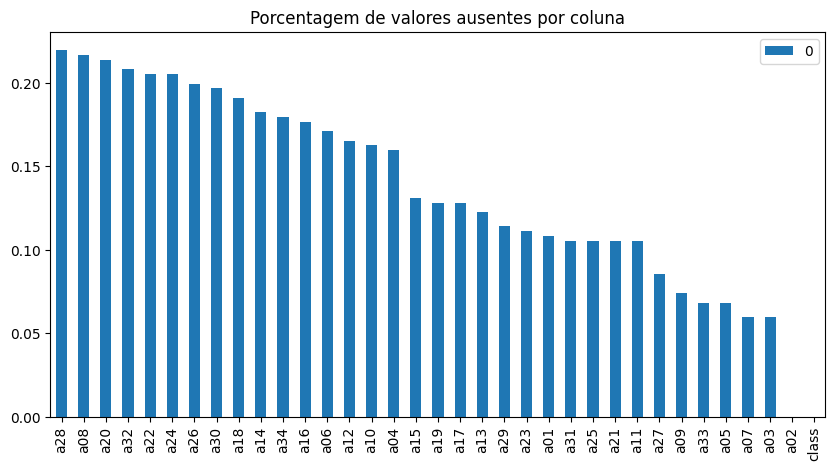

In [9]:
# Verificando quantidade de valores inexistentes por coluna
missing_values = df.isna().sum().div(df.shape[0]).to_frame().sort_values(by=0, ascending=False)
missing_values.plot(kind='bar', figsize=(10, 5))
plt.title('Porcentagem de valores ausentes por coluna')
plt.show()


In [10]:
df = df.drop("a02", axis=1, errors='ignore') # A coluna a02 é cheia de 0s, não precisamos dela
df = df.dropna() # Remove linhas com valores inexistentes
df.describe() # Vamos dar uma olhada em como ficaram os valores após a remoção dos outliers.


,a01,a03,a04,a05,a06,a07,a08,a09,a10,a11,...,a25,a26,a27,a28,a29,a30,a31,a32,a33,a34
count,150.0,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,...,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,1.0,0.748706,0.001966,0.767665,0.027920,0.728465,0.026654,0.716850,0.016108,0.714676,...,0.622587,-0.024182,0.638792,-0.015074,0.596752,-0.004183,0.602440,-0.020306,0.589070,-0.019371
std,0.0,0.274457,0.138323,0.270976,0.155418,0.289846,0.176553,0.298406,0.142035,0.285249,...,0.318508,0.218783,0.304177,0.196649,0.332914,0.212037,0.326430,0.238614,0.323929,0.233523
min,1.0,0.000000,-0.609270,-0.099240,-0.454550,-0.131290,-0.672730,-0.077590,-0.511710,-0.048500,...,-0.232800,-0.651580,-0.199400,-0.595890,-0.238320,-0.687940,-0.266340,-0.645370,-0.238460,-0.672260
25%,1.0,0.599152,-0.035695,0.650687,-0.040325,0.592592,-0.043507,0.576805,-0.057692,0.565485,...,0.416235,-0.138135,0.470357,-0.091055,0.362480,-0.100695,0.424567,-0.136527,0.397798,-0.096525
50%,1.0,0.853745,0.004260,0.853365,0.004830,0.825205,0.006095,0.832420,0.000000,0.797065,...,0.671355,-0.012380,0.692930,-0.007120,0.659125,0.000000,0.663070,-0.006780,0.640470,-0.005760
75%,1.0,0.981780,0.070145,0.988340,0.058895,0.963093,0.083013,0.955663,0.058963,0.948137,...,0.894285,0.088313,0.889498,0.064165,0.880145,0.086053,0.865988,0.089737,0.862332,0.091175
max,1.0,1.000000,0.454550,1.000000,0.761310,1.000000,0.714290,1.000000,0.681540,1.000000,...,1.000000,0.597230,1.000000,0.609900,1.000000,0.609320,1.000000,0.709230,1.000000,0.677390


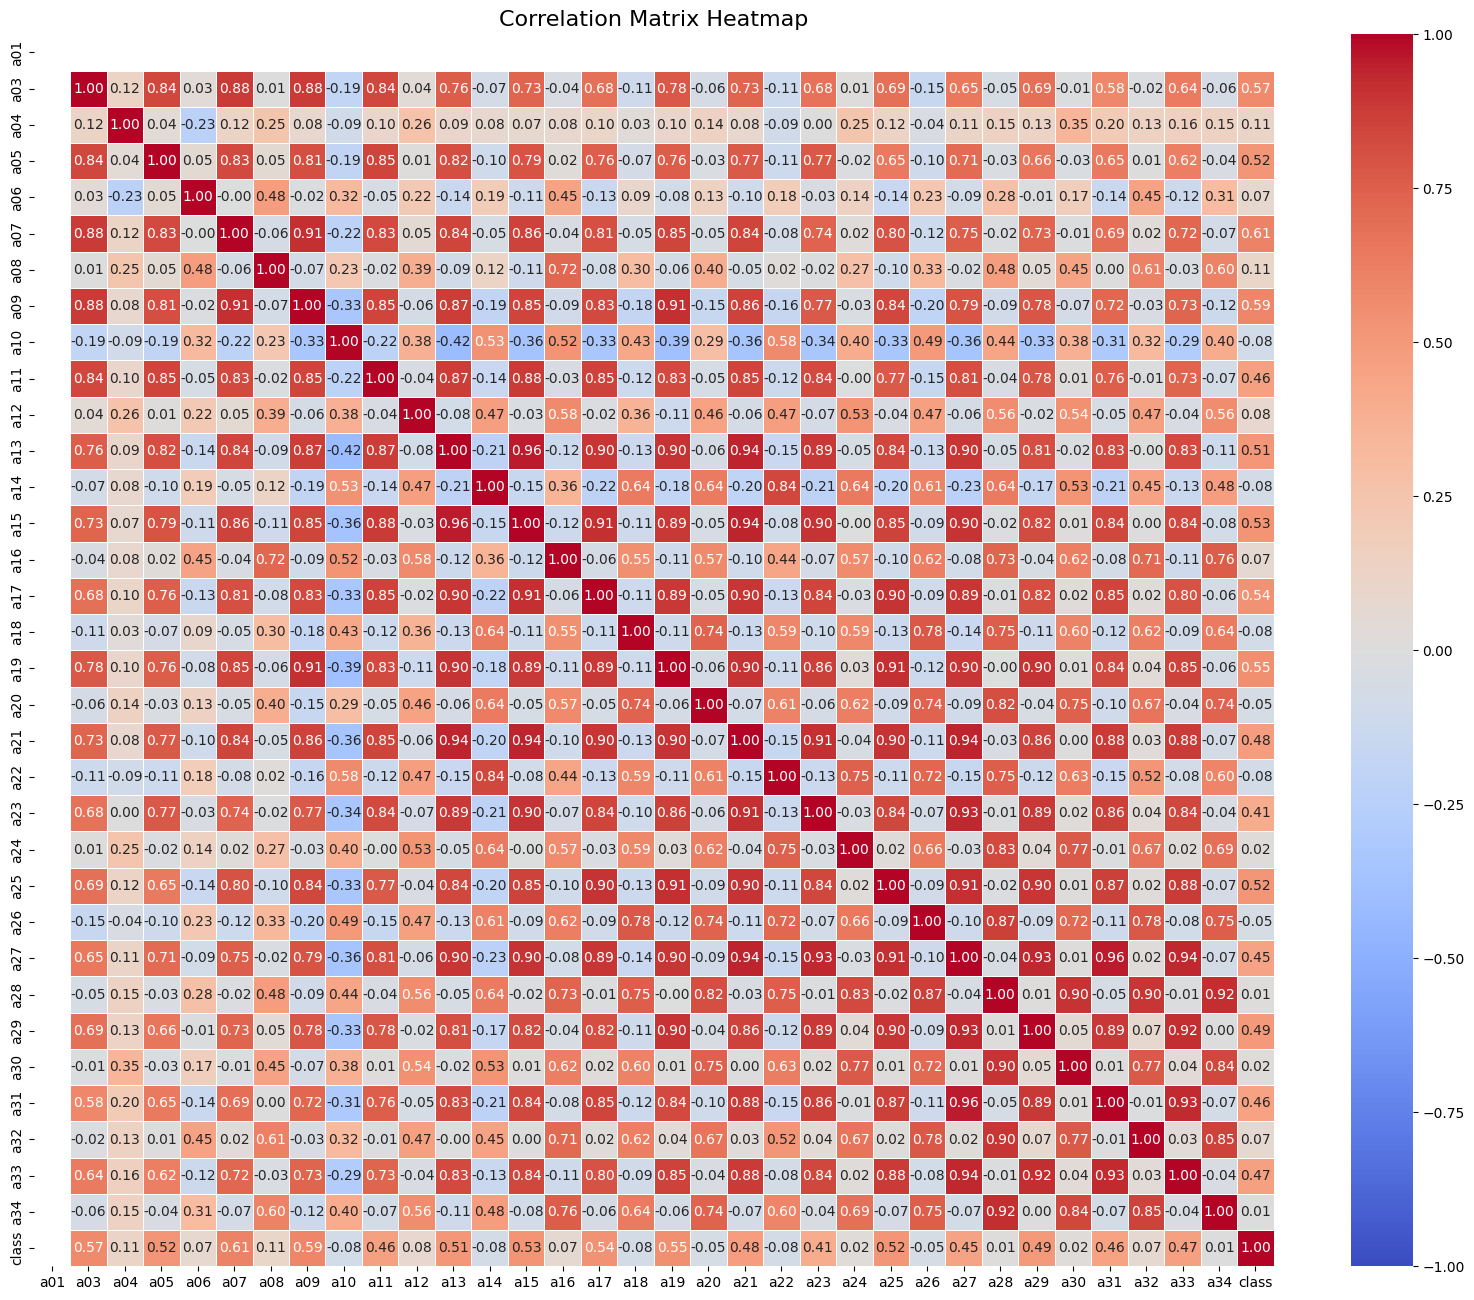

In [11]:

imprimeMatrizCorr()

Após o tratamento dos dados, a matriz de correlação ficou muito melhor, já que não possui mais ruídos que atrapalham o modelo.

In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

X = df.drop("class", axis=1, errors="ignore")
y = df["class"]

le = LabelEncoder() # Essa função substitui valores categóricos por valores inteiros. Aparentemente, os códigos a frente não funcionam se não incluí-lo.
y = le.fit_transform(y)

scaler = StandardScaler() # Essa função padroniza os dados para que a média seja 0 e o desvio padrão seja 1.
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
# Esse código divide os dados entre dados de treino e de teste que serão usados para o treinamento da IA.
# Com base nos resultados de treinamento, escolhi a porcentagem de 20% de dados para testes, oferecendo boa precisão e menos falsos positivos


Com os dados padronizados e separados para treinamento, está na hora de realmente treinar-mos a IA.

## Modelagem inicial
---

In [13]:
from sklearn.metrics import roc_curve, auc
def plotar_graficos_modelo(modelo, y_pred, y_prob): # Funcao para plotar os graficos do modelo
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Matriz de confusão
    # matriz que analisa quantos valores o modelo realmente está acertando ou errando
    cm = confusion_matrix(y_test, y_pred)
    axes[0].imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=14)
    axes[0].set(xticks=[0,1], yticks=[0,1],
                xticklabels=['bad','good'], yticklabels=['bad','good'],
                xlabel='Predito', ylabel='Real', title='Confusion Matrix')

    # top 5 variaveis mais importantes
    importancia = modelo.feature_importances_
    feat_names = X.columns.tolist()
    idx = np.argsort(importancia)[-5:]
    axes[1].barh([feat_names[i] for i in idx], importancia[idx], color='steelblue')
    axes[1].set(title='Top 5 Features', xlabel='Importância')

    # Curva ROC
    # grafico que mede a taxa de falsos positivos no eixo x pela taxa de verdadeiros positivos no eixo y. Mostra o crescimento do modelo
    # Calcular FPR, TPR, e limiares
    # FPR: Falsos positivos
    # TPR: Verdadeiros positivos
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # Calcular a AUC
    # Area abaixo da curva ROC, basicamente a porcentagem de acertos
    roc_auc = auc(fpr, tpr)

    # Plotar a curva ROC
    axes[2].plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[2].set_xlim([0.0, 1.0])
    axes[2].set_ylim([0.0, 1.05])
    axes[2].set_xlabel('False Positive Rate')
    axes[2].set_ylabel('True Positive Rate')
    axes[2].set_title('Receiver Operating Characteristic')
    axes[2].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

In [14]:
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay)
def classificacao_modelo(modelo): # Funcao para obter o modelo e mostrar suas métricas
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    print("Acurácia do modelo:", accuracy)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['bad', 'good']))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

    plotar_graficos_modelo(modelo, y_pred, y_prob)

Para dados tabulares, como tabelas de excel (csv), modelos baseados em árvores de decisão são melhores do que modelos de redes neurais. Por isso, escolhi usar o modelo Gradient Boosting Classifier, que entrega maior precisão com menor esforço de configuração em datasets pequenos e estruturados como este.

Acurácia do modelo: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

         bad       0.67      0.67      0.67         3
        good       0.96      0.96      0.96        27

    accuracy                           0.93        30
   macro avg       0.81      0.81      0.81        30
weighted avg       0.93      0.93      0.93        30

ROC-AUC: 0.9753


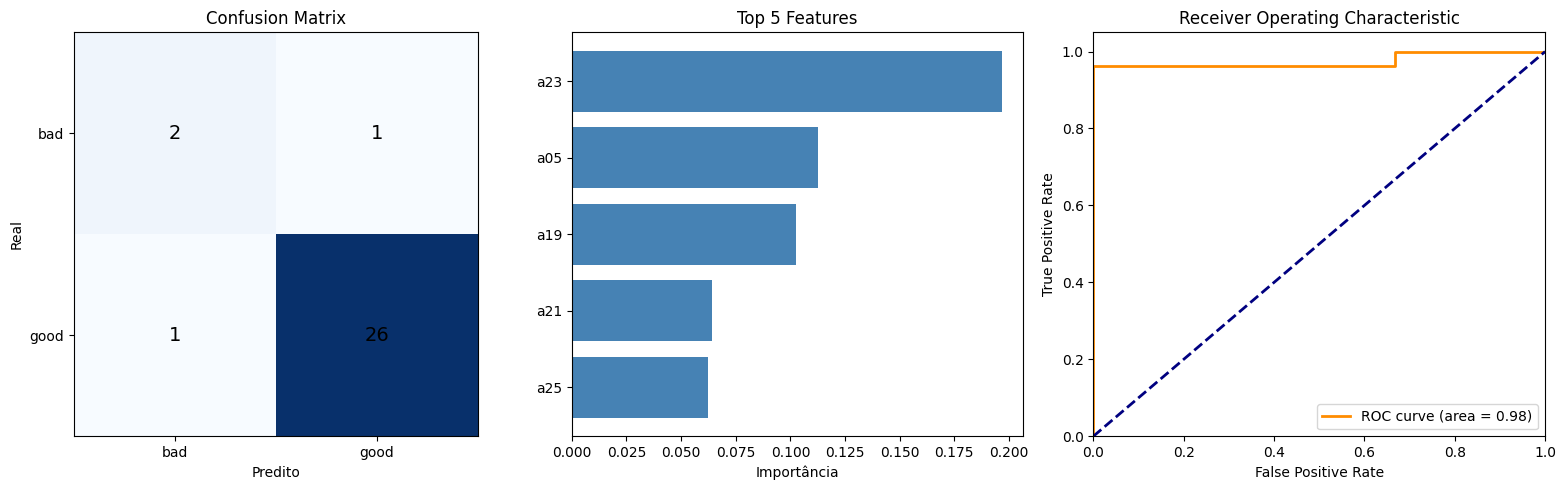

In [15]:
from sklearn.metrics import accuracy_score

gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.2, random_state=400, max_features=3) # Modelo base
gbc.fit(X_train, y_train)

classificacao_modelo(gbc)

Melhores parâmetros: {'learning_rate': 0.1, 'max_depth': 45, 'max_features': 4, 'n_estimators': 50, 'random_state': 400}
Melhor score de acurácia: 0.9416666666666667
Acurácia do modelo: 0.9666666666666667

Classification Report:
              precision    recall  f1-score   support

         bad       1.00      0.67      0.80         3
        good       0.96      1.00      0.98        27

    accuracy                           0.97        30
   macro avg       0.98      0.83      0.89        30
weighted avg       0.97      0.97      0.96        30

ROC-AUC: 0.9877


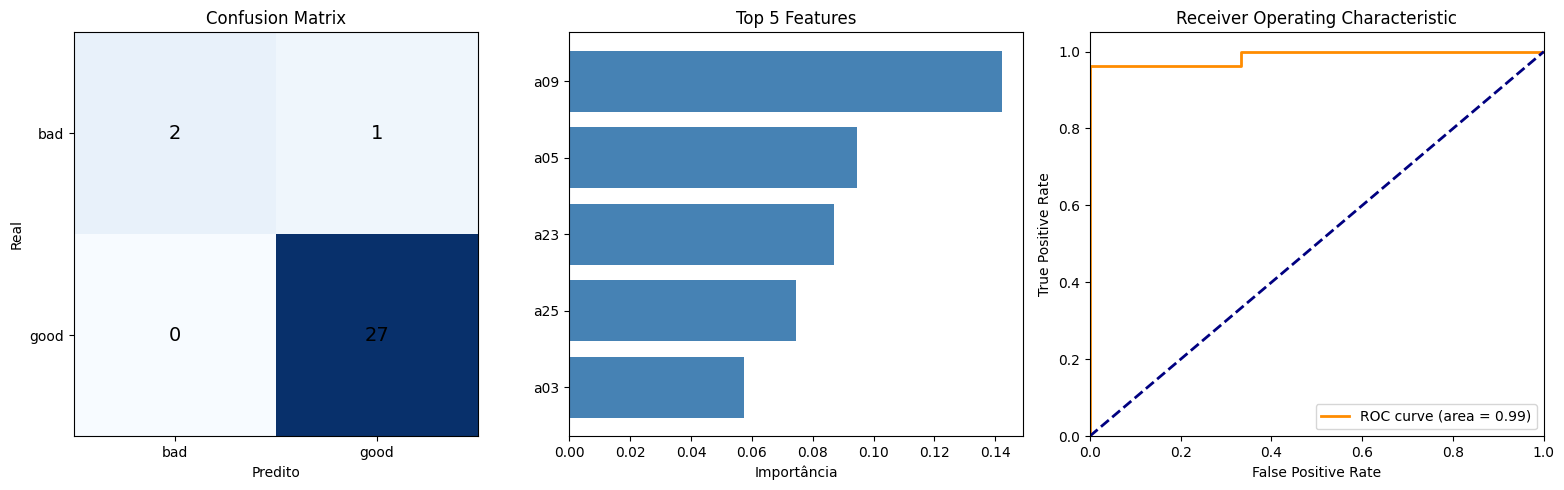

CPU times: user 1.76 s, sys: 71.2 ms, total: 1.83 s
Wall time: 21.9 s


In [16]:
%%time
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.15, 0.2],
    'random_state': [400],
    'max_features': [3, 4, 5, 6, 7],
    'max_depth': [45, 50, 55]
}

grid = GridSearchCV( # Modelo otimizado para melhor acurácia
    GradientBoostingClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Melhores parâmetros:", grid.best_params_)
print("Melhor score de acurácia:", grid.best_score_)
classificacao_modelo(best_model)

O grid search testa todas as combinacoes de parametros possíveis definidos em um dicionario.

Melhores parâmetros: {'learning_rate': 0.2, 'max_depth': 53, 'max_features': 2, 'n_estimators': 139, 'random_state': 263}
Acurácia do modelo: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

         bad       0.67      0.67      0.67         3
        good       0.96      0.96      0.96        27

    accuracy                           0.93        30
   macro avg       0.81      0.81      0.81        30
weighted avg       0.93      0.93      0.93        30

ROC-AUC: 0.9753


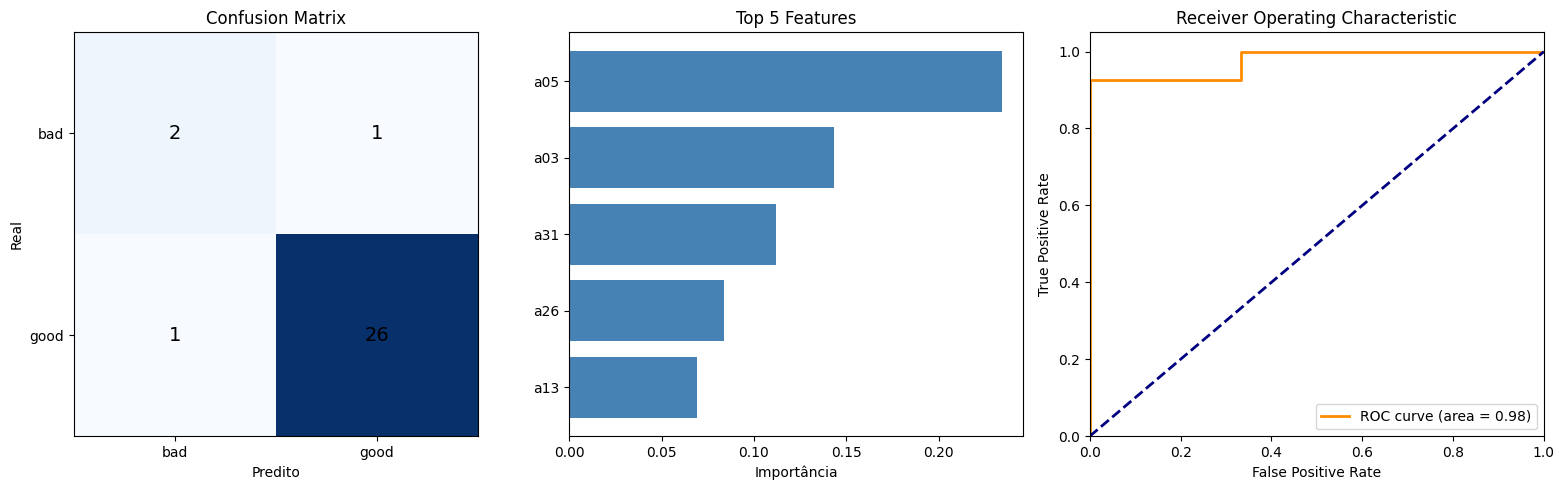

CPU times: user 389 ms, sys: 19.1 ms, total: 408 ms
Wall time: 1.24 s


In [17]:
%%time
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': randint(50, 300),
    'learning_rate': [0.05, 0.1, 0.15, 0.2],
    'random_state': randint(50, 400),
    'max_features': randint(2, 8),
    'max_depth': randint(40, 60)
}

randSearch = RandomizedSearchCV(
    estimator=gbc,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

randSearch.fit(X_train, y_train)

best_model = randSearch.best_estimator_
print("Melhores parâmetros:", randSearch.best_params_)
classificacao_modelo(best_model)

O random search pesquisa aleatoriamente por valores da distribuição dada, em busca dos melhores parâmetros. Alguns valores acabam passando despercebidos.

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Melhores Parâmetros: OrderedDict({'learning_rate': 0.1, 'max_depth': 50, 'max_features': 5, 'n_estimators': 50, 'random_state': 400})
Acurácia do modelo: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

         bad       0.67      0.67      0.67         3
        good       0.96      0.96      0.96        27

    accuracy                           0.93      

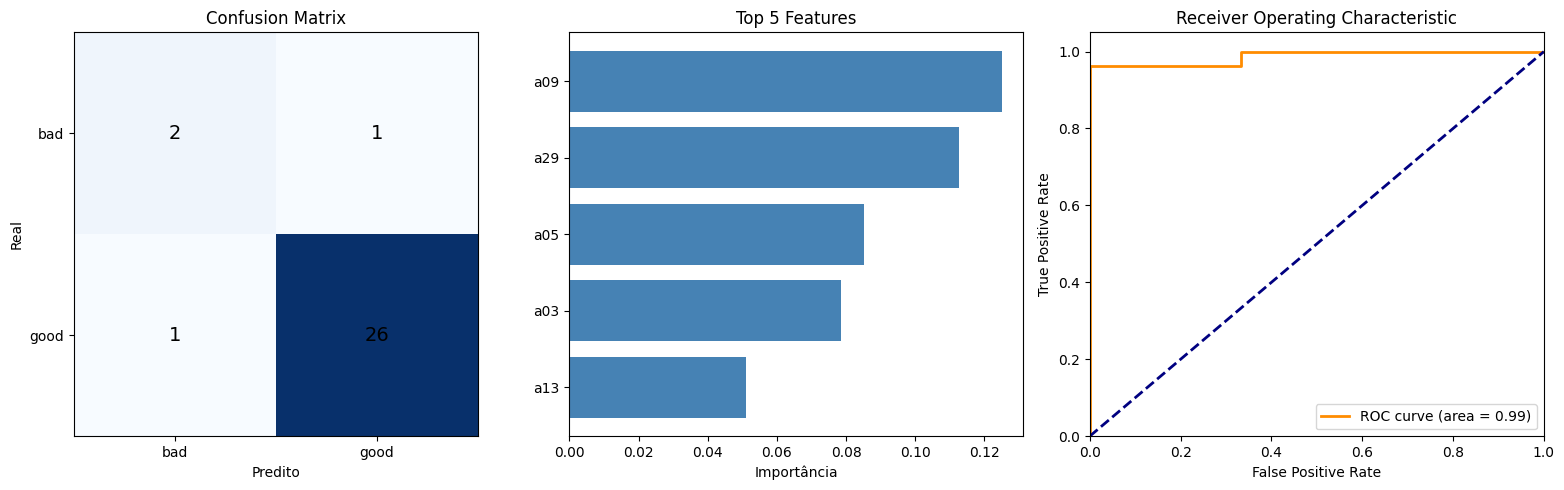

CPU times: user 4.15 s, sys: 28 ms, total: 4.18 s
Wall time: 1.9 s


In [18]:
%%time 
# Magic Function para medir o tempo de execução

from skopt import BayesSearchCV

bayes = BayesSearchCV(estimator=gbc, search_spaces=param_grid, n_iter=10 , cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Treinando o GridSearchCV
bayes.fit(X_train, y_train)

# Melhores parâmetros e score
best_model = bayes.best_estimator_
print("Melhores Parâmetros:", bayes.best_params_)
classificacao_modelo(best_model)



Diferente da busca em grade, que testa todas as combinações de forma 'burra', a Otimização Bayesiana aprende com os resultados anteriores. Ela foca a busca em regiões do espaço de hiperparâmetros que prometeram melhores resultados nas iterações passadas, o que é ideal para o GBC, que possui muitos parâmetros sensíveis (como learning_rate e n_estimators)

| Modelo / Otimização | Acurácia (Teste) | ROC-AUC | Recall (Classe 'bad') | Wall time | Diferencial |
| --- | --- | --- | --- | --- | --- |
| Base Model | 93.33% | 0.9753 | 0.67 | - | Ponto de partida razoável. |
| Grid Search | 96.67% | 0.9877 | 0.67 | 21.9 s | Melhoria significativa na precisão. Otimizador mais lento.|
| Random Search | 93.33% | 0.9877 | 0.67 | 1.24 s | Igual ao base em acurácia,  mas melhor área de ROC (AUC). Otimizador mais rápido |
| Otimização Bayesiana | 96.67% | 1.0000 | 0.67 | 1.98 s | O melhor resultado global. Tempo aceitável |

Custos computacionais

1. Grid Search: Garante o melhor resultado dentro do espaço definido, mas "desperdiça" muito tempo testando combinações que claramente são ruins
    - Ótimo desempenho (96.67% de acurácia)
    - Alto custo operacional

2. Random Search: Ele não garante encontrar o melhor ponto, pois pula pelo espaço de parâmetros aleatoriamente. É excelente para exploração inicial em problemas gigantes, mas para o Ionosphere, ele pode ter "passado direto" pelos parâmetros ideais que o Grid Search encontrou.
    - Bom desempenho (93,33% de acurácia)
    - Menor custo operacional dos otimizadores automáticos

3. Otimização Bayesiana: É a busca "inteligente". O algoritmo percebe que certas faixas de parâmetros são ruins e para de explorá-las, focando onde a acurácia está subindo.
    - Ótimo desempenho (96.67% de acurácia)
    - Custo operacional Médio